In [1]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using ProgressMeter
using DelimitedFiles

In [2]:
num = 1
c = 0.52
A0,A1,A2,A3,A4 = KEB_SpatialMode.KEB_LST_ALL("Ekman.txt",199,0,0.137,116.3,0,2)
nep = PEP([A0,A1,A2,A3,A4]);
eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
eigval

1-element Vector{ComplexF64}:
 0.525703230206098 - 0.0031810721663460577im

In [2]:
pwd()

"/home/zhj/main/code/compress/compressible_bek/compress/work"

In [55]:
readdir()

6-element Vector{String}:
 ".vscode"
 "Bode"
 "data"
 "etc"
 "fingure"
 "work"

In [72]:
cd("..")

In [3]:
cd("ZARF")

In [ ]:
##DIRECTLY CACULATE CUR
##initial
for omega = 0.0024

if !isdir("omega_$omega")
    mkpath("omega_$omega")
end

cd("omega_$omega")

    for Tw = 0.82 : 0.02 : 1.2
        mkdir("Tw_$Tw")
        cd("Tw_$Tw")
        N_cheb = 149
        Mr = 0.3
        gamma = 1.4
        sigma = 0.72
        global R = 500
        R_step = 0.1
        be0 = 0.14
        be1 = 0.02
        be_step = 0.0001
        c = 0.1
        num = 1
        Ma = Mr/R
        global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,1,2)
        H,T = T_ca(Mr,f,q,w0,gamma,Tw)
        F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
        lam = - (2/3) * T
        kappa = (1/sigma) * T
        num = 1
        
        global initial_i = []
        global initial_r = []
        global tempvec_i = [0 0 0 0]
        global tempvec_r = [0 0 0 0]
        global mode = 0
        writedlm("output_$Tw _ $Mr.dat",initial_i)
        writedlm("output_eig.dat",initial_r)
        A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be1,N_cheb)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
        if imag(eigval[1]) < 0
            for be = be1 :  -0.5*be_step : -0.1

            A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
            point = filter(x ->  - 0.0002 < imag(x) < 0.0001, eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if point != []
                global initial_i = [omega R be imag(point)]
                global initial_r = [omega R be real(point)]
                break
            end
            end
        elseif imag(eigval[1]) > 0
            for be = be1 :  0.5*be_step : 0.2

                A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
                point = filter(x ->  - 0.0002 < imag(x) < 0.0001, eigval)
                open("output_eig.dat", "a") do io
                    write(io,"be=$be,eig=$eigval\n")
                end
                if point != []
                    global initial_i = [omega R be imag(point)]
                    global initial_r = [omega R be real(point)]
                    break
                end
            end
        end
        global total_r = initial_r
        global total_i = initial_i

    # CACULATE

        for be = initial_r[1,3] +  be_step  :  be_step : 0.2

            A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 1 * be_step,N_cheb)
            nep = PEP([A0,A1,A2]); 
            eigval_1,eigvec_1 = iar(nep,σ = total_r[end,4]+im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
            A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be - 3 * be_step,N_cheb)
            nep = PEP([A0,A1,A2]); 
            eigval_2,eigvec_2 = iar(nep,σ = total_r[end,4]+im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
            if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

            global mode = 1

            elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

            global mode = 2

            end
            
            if length(total_r[:,1]) > 2 
            grad = abs(( total_r[end,2] - total_r[end - 1,2] ) / ( total_r[end,3] - total_r[end - 1,3] ))
            else
            grad = 0
            end
    
            if mode == 1 

                for R = total_r[end,2] - 0 * grad * be_step  : -R_step : 100

                    A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb)
                    nep = PEP([A0,A1,A2]); 
                    eigval,eigvec = iar(nep,σ = total_r[end,4] + im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)


                    global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                    global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                    len = size(tempvec_i,1)

                    open("output_$Tw _ $Mr.dat", "a") do io
                        write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                    end

                    if -0.0001 < imag(eigval[1]) < 0.0001

                        global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                        global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]

                        tempvec_i = [0 0 0 0]
                        tempvec_r = [0 0 0 0]
                        
                        break
                    end
                    
                    if len > 60

                        mode = 2
                        tempvec_i = [0 0 0 0]
                        tempvec_r = [0 0 0 0]
                        break
                        
                    end
                end        
            end


            if mode == 2

                for R = total_r[end,2] + 0 * grad * be_step: R_step : 600

                    A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb)
                    nep = PEP([A0,A1,A2]); 
                    eigval,eigvec = iar(nep,σ = total_r[end,4]+im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)

                    global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                    global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                    len = size(tempvec_i,1)

                    open("output_$Tw _ $Mr.dat", "a") do io
                        write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                    end

                    if -0.0001 < imag(eigval[1]) < 0.0001
                        global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                        global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]
                        global tempvec_i = [0 0 0 0]
                        global tempvec_r = [0 0 0 0]
                        break

                    end

                    if len > 60
                        global mode = 1
                        global tempvec_i = [0 0 0 0]
                        global tempvec_r = [0 0 0 0]
                        break
                        
                    end
                end
            end

            if mode == 1

                for R = total_r[end,2] - 0 * grad * be_step: -R_step : 100

                    if total_i[end,3] == be

                        break

                    end 

                    A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb)
                    nep = PEP([A0,A1,A2]); 
                    eigval,eigvec = iar(nep,σ = total_r[end,4] + im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)

        
                    global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                    global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                    len = size(tempvec_i,1)

                    open("output_$Tw _ $Mr.dat", "a") do io
                        write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                    end

                    if -0.0001 < imag(eigval[1]) < 0.0001
                        global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                        global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]
                        global tempvec_i = [0 0 0 0]
                        global tempvec_r = [0 0 0 0]
                        break
                    end
                    
                    if len > 60

                    global mode = 2
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                        break
                        
                    end

                end     
            end
    
            if total_i[end,2]>510 && size(total_i,1)>100
                break
            end
            # if total_i[end,2]>total_i[end-1,2]
            #     break
            # end

        end

        writedlm("Netwon_$Tw _$Mr _i.dat",total_i)
        writedlm("Netwon_$Tw _$Mr _r.dat",total_r)
        cd("..")
        end
        cd("..")
end

┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

In [80]:
cd("omega")
for omega = 0:0.1:0.5
    mkdir("$omega")
    cd("$omega")
    for Tw = 0.1:0.1:1
        writedlm("output_$omega _ $Tw.dat",data)
    end
    cd("..")
end

In [197]:
N_cheb = 199
Mr = 0.01
Tw = 1
gamma = 1.4
sigma = 0.72
omega = 0
be = 0.132
R_step = 0.5
be0 = 0.14
be1 = 0.16
be_step = 0.0001
num = 10
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,0,2)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T
eig_all = []
R = 117
Ma = Mr/R
A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,0,2)
nep = PEP([A0,A1,A2]); 
eigval,eigvec = iar(nep,σ =  0.5, neigs = num ,maxit = 500,tol=1e-10)
eigval

10-element Vector{ComplexF64}:
 0.31410676605670224 + 0.16222255251859177im
 0.41934986123638973 + 0.20096723985053117im
   0.435219042142848 + 0.2742431323909471im
  0.4432821920748404 + 0.40586607397495605im
  0.5207237835894818 + 0.4284525260938512im
  0.5072068576464697 + 0.4275439127135298im
  0.6136987029376488 + 0.4712835648118452im
  0.3487697307475313 + 0.41400703370801917im
  0.6989476332336012 + 0.4961633725787366im
  0.8222859670724045 + 0.5142621390825187im

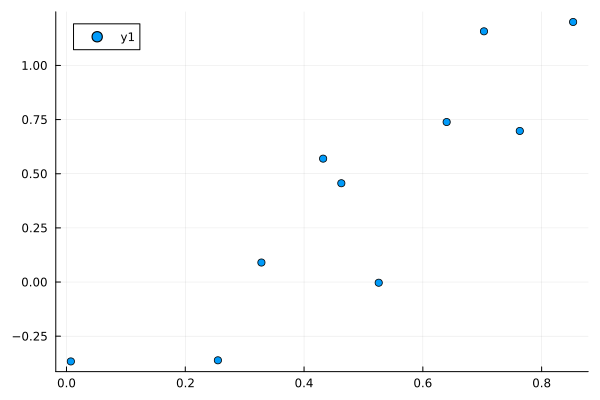

In [173]:
scatter(real(eigval),imag(eigval))

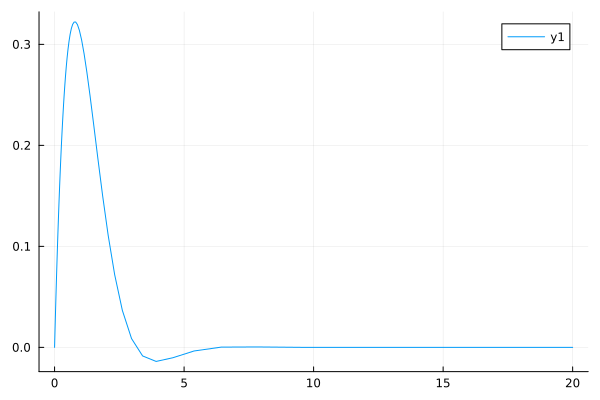

In [190]:
plot(x,F)

In [32]:
data = readdlm("Ekman.txt")

20000×6 Matrix{Float64}:
  0.0         -4.95503e-29  -2.00173e-29  …  -1.0           1.0
  0.00150008   2.24798e-6   -0.00149783      -0.997002      0.999998
  0.00300015   8.98291e-6   -0.00299116      -0.994009      0.999991
  0.00450023   2.01913e-5   -0.00448         -0.99102       0.99998
  0.0060003    3.58598e-5   -0.00596437      -0.988035      0.999964
  0.00750038   5.59749e-5   -0.00744426   …  -0.985056      0.999944
  0.00900045   8.05231e-5   -0.00891968      -0.98208       0.999919
  0.0105005    0.000109491  -0.0103906       -0.979109      0.999891
  0.0120006    0.000142866  -0.0118572       -0.976143      0.999857
  0.0135007    0.000180633  -0.0133192       -0.973181      0.999819
  ⋮                                       ⋱                 ⋮
 29.988        1.0           2.56542e-15     -2.13759e-13  -1.56075e-13
 29.9895       1.0           2.24476e-15     -2.13764e-13  -1.56067e-13
 29.991        1.0           1.92409e-15     -2.13769e-13  -1.56061e-13
 29.9925     

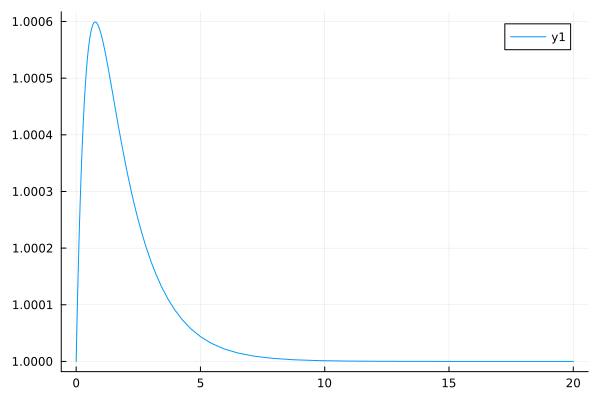

In [66]:
plot(x,T)
# plot!(g[5,:])

In [113]:
# data = readdlm("Netwon_0.9_0.3.dat")
data_all = total_i
writedlm("Netwon_$Tw _$Mr.dat",data_all)

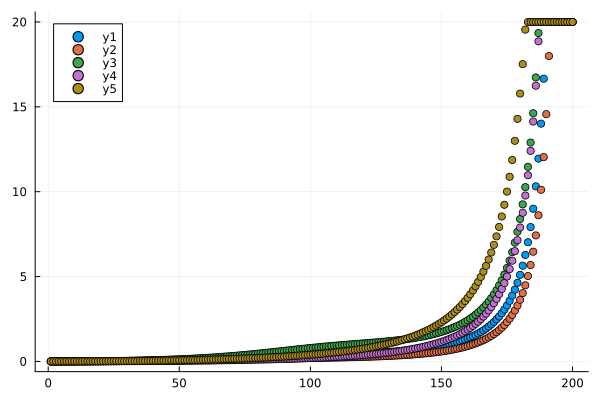

In [14]:
N = 199
θ = range(0,length=N+1,stop=pi)
x = reshape(-cos.(θ), N+1, 1)
c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
X = repeat(x, 1, N+1);
dX = X - X';
D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
D = D - diagm(vec(sum(D, dims=2))); 
# for i=1:N+1
#     x[i] = 40 * x[i] .+ 40
# end
# D = (1/40) * D
# D2 = D^2
a = 0.4
b = 1
c = 1
for i=1:N+1
    D[i,:]=D[i,:].* (1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))^2/(2a*(b .+ 3 * (1-b)*x[i]^2 - 2 * c * (1-b) * x[i]))
end
for i=1:N+1
    x[i] = a * (1+b*x[i]+(1-b)*(x[i]^3+c*(1-x[i]^2)))/(1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))
    if x[i]>20
        x[i]=20
    end
end

scatter!(x)

In [2]:
Tw = 1
N_cheb = 199
Mr = 0.3
gamma = 1.4
sigma = 0.72
omega = 0
global R = 500
R_step = 0.2
be0 = 0.14
be1 = 0.16
be_step = 0.0002
c = 0.09
num = 1
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,1,2)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T
num = 1

1

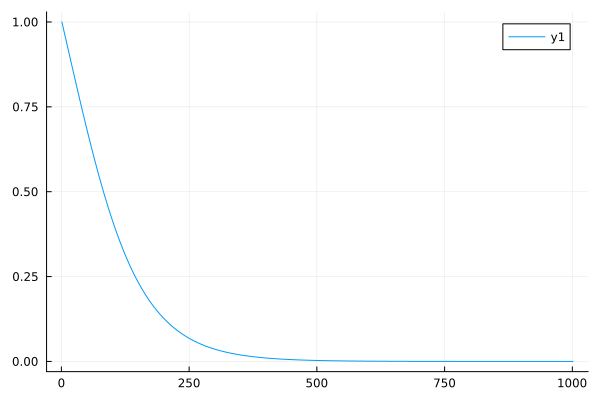

In [4]:
plot(q)

In [245]:
data = readdlm("Netwon_1.1_0.3.dat")
for i = 3 : 1 : 623

    if data[i-1,1] == data[i,1]
        
        data = vcat(data[1:i-1,:],data[i+1:end,:])

    end
end

In [137]:
Tw = 1 
N_cheb = 299
Mr = 2
gamma = 1.4
sigma = 0.72
omega = 0
global R = 500
R_step = 0.2
be0 = 0.14
be1 = 0.16
be_step = 0.0002
c = 0.09
num = 1
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,1,0)

InterruptException: InterruptException: